# Telco Customer Churn Prediction - Exploratory Data Analysis (EDA)

Telecom companies lose revenue when customers leave.

Objective:
Predict which customers are likely to churn.

Business Value:
Enable proactive retention strategies.

ML Framing:
Binary classification.

Target Variable:
Churn

## Feature Description

- customerID : Customer ID
- gender : Whether the customer is a male or a female
- SeniorCitizen : Whether the customer is a senior citizen or not (1, 0)
- Partner : Whether the customer has a partner or not (Yes, No)
- Dependents : Whether the customer has dependents or not (Yes, No)
- tenure : Number of months the customer has stayed with the company
- PhoneService : Whether the customer has a phone service or not (Yes, No)
- MultipleLines : Whether the customer has multiple lines or not (Yes, No, No phone service)
- InternetService : Customer’s internet service provider (DSL, Fiber optic, No)
- OnlineSecurity : Whether the customer has online security or not (Yes, No, No internet service)
- OnlineBackup : Whether the customer has online backup or not (Yes, No, No internet service)
- DeviceProtection : Whether the customer has device protection or not (Yes, No, No internet service)
- TechSupport : Whether the customer has tech support or not (Yes, No, No internet service)
- StreamingTV : Whether the customer has streaming TV or not (Yes, No, No internet service)
- StreamingMovies : Whether the customer has streaming movies or not (Yes, No, No internet service)
- Contract : The contract term of the customer (Month-to-month, One year, Two year)
- PaperlessBilling : Whether the customer has paperless billing or not (Yes, No)
- PaymentMethod : Whether the customer has paperless billing or not (Yes, No)
- MonthlyCharges : The amount charged to the customer monthly
- TotalCharges : The total amount charged to the customer
- Churn : Whether the customer churned or not (Yes or No)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#set the visual style
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

## Import & Load Data

In [2]:
original_data = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/ML Supervised Project/Data/Telco customer churn analysis.csv")

### Understanding Dataset

In [3]:
original_data.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
822,7975-TZMLR,Male,0,No,No,47,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Electronic check,103.10,4889.3,No
4881,2305-MRGLV,Male,0,Yes,No,28,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,No,Bank transfer (automatic),76.55,2065.4,No
2165,5039-LZRQT,Female,0,No,No,13,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.20,273.25,No
3827,6870-ECSHE,Female,0,No,No,2,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.45,34.8,No
904,0379-DJQHR,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Credit card (automatic),81.35,5398.6,No
4040,9581-GVBXT,Male,0,Yes,Yes,59,No,No phone service,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,34.80,1980.3,No
5285,9479-HYNYL,Female,0,Yes,No,71,Yes,No,DSL,No,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),80.70,5705.05,No
5650,6047-SUHPR,Male,0,Yes,Yes,39,Yes,No,DSL,Yes,Yes,Yes,No,No,No,One year,No,Electronic check,59.80,2343.85,No
6653,8799-OXZMD,Female,0,No,No,28,No,No phone service,DSL,No,No,Yes,No,No,No,Month-to-month,Yes,Mailed check,29.75,790.7,No
5360,4919-IKATY,Male,0,Yes,Yes,5,Yes,Yes,Fiber optic,Yes,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,84.50,453.75,Yes


In [4]:
original_data.shape

(7043, 21)

In [5]:
original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Observation:
**TotalCharges** is stored as object instead of numeric.

Potential data quality issue.

### Summary Statistics and Distributions

In [6]:
original_data.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [7]:
original_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### DATA QUALITY ASSESSMENT

In [8]:
#Identify Identifier Columns
original_data['customerID'].nunique()/len(original_data)

1.0

customerID will be excluded from modeling.

Reason:
identifier leakage / no predictive value.

In [9]:
#Investigate TotalCharges Problem - datatype was object
(original_data['TotalCharges'] == ' ').sum()

np.int64(11)

Blank string values found in TotalCharges.
Causing incorrect dtype classification.

### Missing Value

In [10]:
print("Null Values In Each Columns")

total = original_data.isnull().sum().sort_values(ascending = False)
percent = (original_data.isnull().sum()/original_data.isnull().count()*100).sort_values(ascending = False)
pd.concat([total, percent], axis=1, keys=['Total', 'Percent']).transpose()

Null Values In Each Columns


,customerID,DeviceProtection,TotalCharges,MonthlyCharges,PaymentMethod,PaperlessBilling,Contract,StreamingMovies,StreamingTV,TechSupport,OnlineBackup,gender,OnlineSecurity,InternetService,MultipleLines,PhoneService,tenure,Dependents,Partner,SeniorCitizen,Churn
Total,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Percent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Missing values exist in TotalCharges due to invalid blank strings after conversion.

### Duplicate Records

In [11]:
original_data.duplicated().sum()

np.int64(0)

## TARGET ANALYSIS

In [12]:
original_data['Churn'].value_counts(normalize=True).round(4) * 100

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

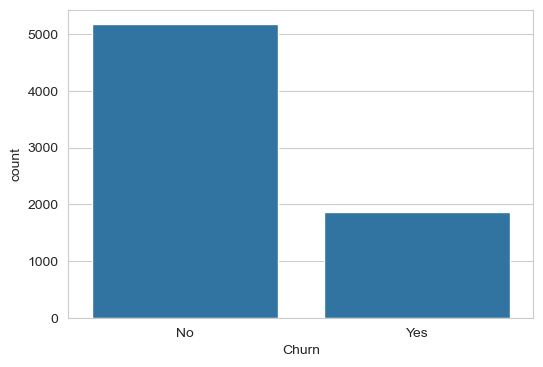

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=original_data, x='Churn')
plt.show()

Class imbalance detected.
Accuracy alone will not be reliable.
Evaluation should prioritize ROC-AUC, Recall, F1.

## FEATURE CATEGORIZATION

In [14]:
#categorized based on data type and business meaning - better preprocessing and visualization

numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

binary_cat_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

multi_cat_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

target_col = 'Churn'

## Visual Analysis

### Tenure VS Churn

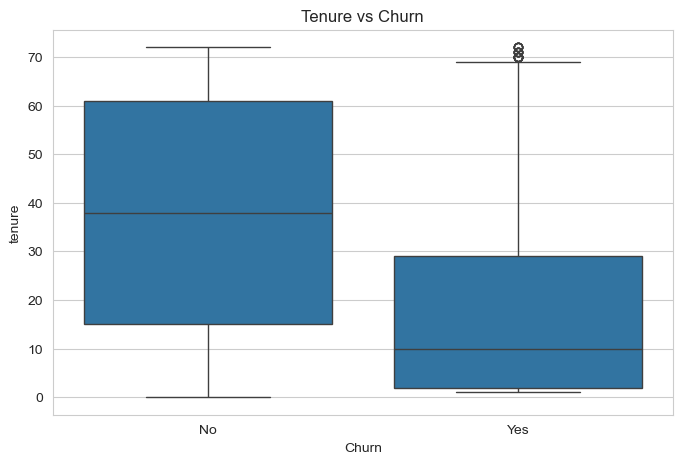

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(data=original_data, x='Churn', y='tenure')
plt.title("Tenure vs Churn")
plt.show()

New customers are at highest **churn risk**.

## Monthly Charges VS CHURN

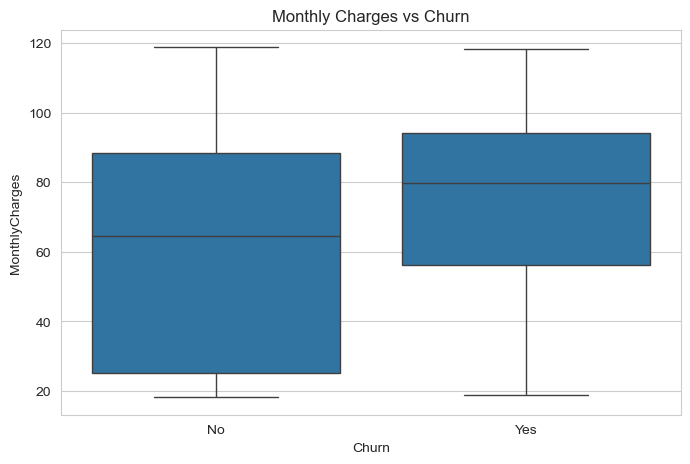

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=original_data, x='Churn', y='MonthlyCharges')
plt.title("Monthly Charges vs Churn")
plt.show()

Higher monthly charges → higher churn.

## CONTRACT TYPE vs CHURN

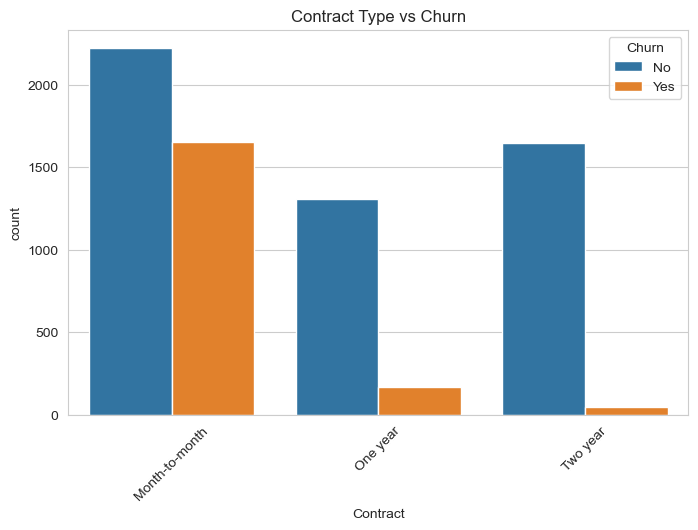

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(data=original_data, x='Contract', hue='Churn')
plt.title("Contract Type vs Churn")
plt.xticks(rotation=45)
plt.show()

Longer commitments improve retention.

## Correlation Heatmap

In [18]:
original_data['TotalCharges'] = pd.to_numeric(
    original_data['TotalCharges'],
    errors='coerce'
)

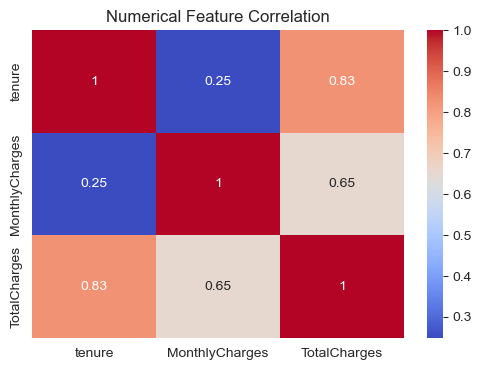

In [19]:
corr = original_data[numerical_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Numerical Feature Correlation")
plt.show()

TotalCharges ↔ tenure

TotalCharges ≈ tenure × monthly charges

# Outlier Detection

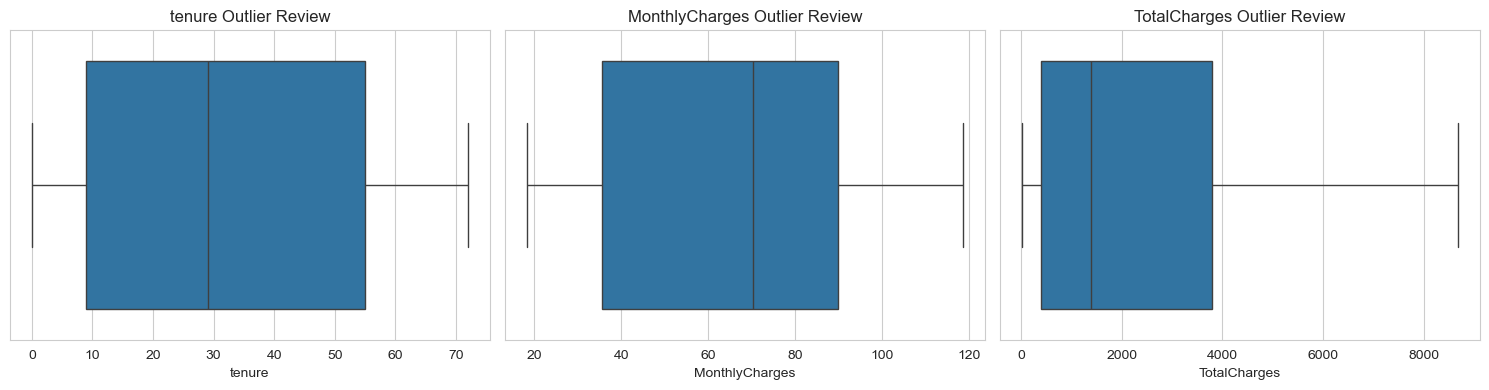

In [20]:
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(15, 4))

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=original_data[col], ax=axes[i])
    axes[i].set_title(f"{col} Outlier Review")

plt.tight_layout()
plt.show()

In [21]:
import pandas as pd

outlier_summary = {}

for col in numerical_cols:
    Q1 = original_data[col].quantile(0.25)
    Q3 = original_data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = original_data[(original_data[col] < lower_bound) | (original_data[col] > upper_bound)]
    
    outlier_summary[col] = {
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outliers.shape[0],
        "Outlier Percentage (%)": round((outliers.shape[0] / len(original_data)) * 100, 2)
    }

outlier_df = pd.DataFrame(outlier_summary).T
outlier_df

,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
tenure,-60.00000,124.00000,0.0,0.0
MonthlyCharges,-46.02500,171.37500,0.0,0.0
TotalCharges,-4688.48125,8884.66875,0.0,0.0


Based on the plots, there are actually no outliers in tenure, MonthlyCharges, or TotalCharges

# EDA Summary

## Key Business Insights

1. Customers with shorter tenure show significantly higher churn risk.

2. Higher monthly charges appear associated with increased churn.

3. Month-to-month contract customers churn substantially more than long-term contract customers.

4. Customers without technical support show higher churn.

5. Payment behavior may be associated with retention differences.

6. TotalCharges is strongly influenced by tenure and monthly billing.

## Preprocessing Decisions

- Drop **customerID**
- Convert **TotalCharges** to numeric
- Median imputation for numeric missing values
- Most frequent imputation for categorical missing values
- One-hot encode categorical features
- Scale numerical features
- Retain valid outliers

## Preprocessing

In [22]:
# Feature / Target Separation

In [23]:
X = original_data.drop('Churn',axis=1)
y = original_data['Churn']

X = X.drop('customerID',axis=1) 

X['TotalCharges'] = pd.to_numeric(
    X['TotalCharges'],
    errors='coerce'
)

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,
                                                 stratify=y,
                                                 random_state=42
                                                )

Dataset is split before preprocessing to prevent data leakage.

In [24]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64
Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64


Features are categorized according to preprocessing requirements.

### Save Train/Test CSV

In [25]:
train_df = X_train.copy()
train_df['Churn'] = y_train

test_df = X_test.copy()
test_df['Churn'] = y_test

train_df.to_csv("C:/Users/Dell/OneDrive/Desktop/ML Supervised Project/Data/train.csv", index=False)
test_df.to_csv("C:/Users/Dell/OneDrive/Desktop/ML Supervised Project/Data/test.csv", index=False)

In [26]:
print(train_df.shape)
print(test_df.shape)

(5634, 20)
(1409, 20)


### Import preprocessor

In [27]:
import sys
import os

sys.path.append(r"C:\Users\Dell\OneDrive\Desktop\ML Supervised Project")

In [28]:
from src.preprocessing import build_preprocessor
#preprocessing
preprocessor = build_preprocessor()

In [29]:
preprocessor = build_preprocessor()
print("pipeline steps :",preprocessor)

pipeline steps : ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtecti

## Completed:
- raw data cleaning
- leakage-safe train/test split
- assignment-compliant train.csv and test.csv generation
- reusable production preprocessing module creation
- preprocessing architecture validation

In [30]:
from src.preprocessing import build_preprocessor
from src.model import (
    baseline_model,
    decision_tree_model,
    random_forest_model,
    gradient_boosting_model
)
from src.utils import evaluate_model

## Logistic Regression Baseline

In [31]:
baseline = baseline_model(preprocessor)
baseline_results = evaluate_model(
    baseline,
    X_train,
    X_test,
    y_train,
    y_test
)

Classification Report
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix
[[926 109]
 [165 209]]

Metrics
Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1 Score : 0.6040
ROC AUC  : 0.8419


## Decision Tree Benchmark

In [32]:
tree = decision_tree_model(build_preprocessor())

tree_results = evaluate_model(
    tree,
    X_train,
    X_test,
    y_train,
    y_test
)

Classification Report
              precision    recall  f1-score   support

          No       0.82      0.80      0.81      1035
         Yes       0.48      0.51      0.49       374

    accuracy                           0.73      1409
   macro avg       0.65      0.66      0.65      1409
weighted avg       0.73      0.73      0.73      1409


Confusion Matrix
[[833 202]
 [185 189]]

Metrics
Accuracy : 0.7253
Precision: 0.4834
Recall   : 0.5053
F1 Score : 0.4941
ROC AUC  : 0.6549


## Random Forest Benchmark

In [33]:
rf = random_forest_model(build_preprocessor())

rf_results = evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

Classification Report
              precision    recall  f1-score   support

          No       0.82      0.89      0.86      1035
         Yes       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409


Confusion Matrix
[[924 111]
 [196 178]]

Metrics
Accuracy : 0.7821
Precision: 0.6159
Recall   : 0.4759
F1 Score : 0.5370
ROC AUC  : 0.8176


## Gradient Boosting Benchmark

In [34]:
gb = gradient_boosting_model(build_preprocessor())

gb_results = evaluate_model(
    gb,
    X_train,
    X_test,
    y_train,
    y_test
)

Classification Report
              precision    recall  f1-score   support

          No       0.84      0.91      0.87      1035
         Yes       0.67      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix
[[940  95]
 [178 196]]

Metrics
Accuracy : 0.8062
Precision: 0.6735
Recall   : 0.5241
F1 Score : 0.5895
ROC AUC  : 0.8434


### COMPARISON 

In [35]:
results_df = pd.DataFrame([
    ["Logistic Regression", baseline_results],
    ["Decision Tree", tree_results],
    ["Random Forest", rf_results],
    ["Gradient Boosting", gb_results]
], columns=["Model", "Metrics"])
results_expanded = pd.concat(
    [
        results_df.drop("Metrics", axis=1),
        results_df["Metrics"].apply(pd.Series)
    ],
    axis=1
)
results_expanded = pd.concat(
    [
        results_df.drop("Metrics", axis=1),
        results_df["Metrics"].apply(pd.Series)
    ],
    axis=1
)

In [36]:
results_expanded

,Model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841871
1,Decision Tree,0.725337,0.483376,0.505348,0.494118,0.654850
2,Random Forest,0.782115,0.615917,0.475936,0.536953,0.817581
3,Gradient Boosting,0.806246,0.673540,0.524064,0.589474,0.843362


## Model benchmarking revealed:

1. Decision Tree significantly underperformed and will be excluded.

2. Random Forest did not outperform simpler baseline models.

3. Logistic Regression delivered the strongest recall and F1 score, making it highly competitive for churn detection.

4. Gradient Boosting achieved the highest ROC-AUC and accuracy.

Shortlisted for tuning:
- Logistic Regression
- Gradient Boosting

## HyperparameterTuning And crossvalidation-Model Comparison

In [37]:
from src.preprocessing import build_preprocessor
from src.model import (
    tune_logistic_regression,
    tune_gradient_boosting
)
from src.utils import evaluate_model, save_model

## Logistic Regression Hyperparameter Tuning

Logistic Regression performed strongly during benchmarking, particularly in recall and F1 score.

Hyperparameter tuning is performed using GridSearchCV with 5-fold cross-validation to identify the optimal configuration.

Parameters explored:
- regularization strength (`C`)
- class imbalance handling (`class_weight`)

Evaluation metric:
- ROC-AUC

ROC-AUC is selected because churn prediction requires strong ranking ability between churn and non-churn customers.

In [38]:
logistic_grid = tune_logistic_regression(
    build_preprocessor()
)
logistic_grid.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__C': [0.01, 0.1, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__penalty': ['l2']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [44]:
print(round(logistic_grid.best_score_,4))
print(logistic_grid.best_params_)

0.8459
{'classifier__C': 10, 'classifier__class_weight': None, 'classifier__penalty': 'l2'}


The best cross-validation ROC-AUC score and corresponding hyperparameters were identified through exhaustive search.

This score reflects average validation performance across 5 folds and provides a more robust estimate than a single train-test split.

In [43]:
logistic_results = evaluate_model(
    logistic_grid.best_estimator_,
    X_train,
    X_test,
    y_train,
    y_test
)

Classification Report
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix
[[926 109]
 [165 209]]

Metrics
Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1 Score : 0.6040
ROC AUC  : 0.8411


## Gradient Boosting Hyperparameter Tuning

Gradient Boosting achieved the highest ROC-AUC during initial benchmarking, making it a strong candidate for optimization.

Hyperparameter tuning is performed using GridSearchCV with 5-fold cross-validation.

Parameters explored:
- number of estimators
- learning rate
- tree depth

Evaluation metric:
- ROC-AUC

The objective is to improve ranking performance while controlling overfitting.

In [45]:
gb_grid = tune_gradient_boosting(
    build_preprocessor()
)
gb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [2, 3], 'classifier__n_estimators': [100, 150, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [46]:
print(gb_grid.best_score_)
print(gb_grid.best_params_)

0.8493207438136154
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 2, 'classifier__n_estimators': 200}


In [47]:
gb_results = evaluate_model(
    gb_grid.best_estimator_,
    X_train,
    X_test,
    y_train,
    y_test
)

Classification Report
              precision    recall  f1-score   support

          No       0.83      0.91      0.87      1035
         Yes       0.66      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix
[[939  96]
 [187 187]]

Metrics
Accuracy : 0.7991
Precision: 0.6608
Recall   : 0.5000
F1 Score : 0.5693
ROC AUC  : 0.8457


In [48]:
#Final Comparison

final_results = pd.DataFrame([
    ["Tuned Logistic Regression", logistic_results],
    ["Tuned Gradient Boosting", gb_results]
], columns=["Model", "Metrics"])

In [49]:
final_expanded = pd.concat(
    [
        final_results.drop("Metrics", axis=1),
        final_results["Metrics"].apply(pd.Series)
    ],
    axis=1
)

final_expanded.sort_values(
    by="roc_auc",
    ascending=False
)

,Model,accuracy,precision,recall,f1,roc_auc
1,Tuned Gradient Boosting,0.799148,0.660777,0.500000,0.569254,0.845688
0,Tuned Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841091


The tuned shortlisted models are compared using key business-relevant evaluation metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Primary decision criteria:
- ROC-AUC (overall ranking ability)
- Recall (ability to identify churners)

This comparison determines the final production candidate.

## Final Model Selection

After hyperparameter tuning and cross-validation, Tuned Logistic Regression was selected as the final production model.

Although Tuned Gradient Boosting achieved a slightly higher ROC-AUC score (0.8457 vs 0.8411), the improvement was marginal.

Tuned Logistic Regression demonstrated:

- higher accuracy
- significantly better recall
- higher F1 score
- competitive ROC-AUC
- lower model complexity
- faster inference
- stronger interpretability

Since customer churn prediction prioritizes identifying at-risk customers, recall was considered a critical business metric.

Therefore, Tuned Logistic Regression was selected as the final model.

In [51]:
#Final Model 
best_model = logistic_grid.best_estimator_
save_model(best_model)

Model saved to C:/Users/Dell/OneDrive/Desktop/ML Supervised Project/notebook/model_pipeline.pkl


The final Logistic Regression pipeline is serialized using joblib.

The saved artifact includes:
- preprocessing pipeline
- trained Logistic Regression classifier

Saving the complete pipeline ensures identical preprocessing behavior during deployment and inference.